# Riffs

Notes: I am following along with the M06 Clustering Notes, the M06 Similarity Notes, 

## Setup

### Import Libraries

In [166]:
# import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist, jensenshannon
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='white')
os.makedirs('plots', exist_ok=True)

### Configure

In [167]:
# # specify OHCO and bags
# OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']

# bags = dict(
#     SENTS = OHCO[:4],
#     PARAS = OHCO[:3],
#     CHAPS = OHCO[:2],
#     BOOKS = OHCO[:1]
# )

### Load Data

In [168]:
# load in tables
LIB = pd.read_csv('data/LIB.csv', sep='\t').set_index('book_id')
THETA = pd.read_csv('data/LDA_THETA.csv', sep='\t').set_index(['book_id', 'chap_num'])
PHI = pd.read_csv('data/LDA_PHI.csv', sep='\t').set_index('topic_id')
TOPICS = pd.read_csv('data/LDA_TOPICS.csv', sep='\t').set_index('topic_id')
VOCAB_W2V = pd.read_csv('data/VOCAB_W2V.csv', sep='\t').set_index('term_str')

## Riff 1: Hierarchical Clustering of Books by LDA Topic Profile

### Aggregate THETA to Book Level

In [169]:
THETA_BOOKS = THETA.groupby('book_id').mean() # use mean not sum because raw aggregation is sensitive to document size

### Compute Pairwise Jensen-Shannon Distance

Note that unlike TFIDF in the M06 Clustering notes, my THETA table is already a probability distribution (doc-topic) where each row sums to ~1 so I do not need a normalization step.

In [170]:
# create condensed distance matrix (list of pair distances as flat 1D array that leaves out the diagonal (A to A = 0) and the lower triangle (redundant A to B = B to A))
# so instead of a 22x22 matrix, I get an array of 22x21/2 = 231 values
condensed = pdist(THETA_BOOKS, 'jensenshannon') # use jensen shannon for distance

In [171]:
len(condensed)

231

### Cluster and Visualize

In [172]:
# create short titles for the leaves
short_titles = {
    'giants-bread':                              'Giants Bread *',
    'the-adventure-of-the-cheap-flat':           'PI: Cheap Flat',
    'the-adventure-of-the-egyptian-tomb':        'PI: Egyptian Tomb',
    'the-adventure-of-the-italian-nobleman':     'PI: Italian Nobleman',
    'the-adventure-of-the-western-star':         'PI: Western Star',
    'the-big-four':                              'The Big Four',
    'the-case-of-the-missing-will':              'PI: Missing Will',
    'the-disappearance-of-mr-davenheim':         'PI: Davenheim',
    'the-jewel-robbery-at-the-grand-metropolitan': 'PI: Grand Metropolitan',
    'the-kidnapped-prime-minister':              'PI: Prime Minister',
    'the-man-in-the-brown-suit':                 'Man in the Brown Suit',
    'the-million-dollar-bond-robbery':           'PI: Bond Robbery',
    'the-murder-at-the-vicarage':                'Murder at the Vicarage',
    'the-murder-of-roger-ackroyd':               'Roger Ackroyd',
    'the-murder-on-the-links':                   'Murder on the Links',
    'the-mysterious-affair-at-styles':           'Styles',
    'the-mystery-of-hunters-lodge':              'PI: Hunters Lodge',
    'the-mystery-of-the-blue-train':             'Blue Train',
    'the-secret-adversary':                      'Secret Adversary',
    'the-secret-of-chimneys':                    'Secret of Chimneys',
    'the-seven-dials-mystery':                   'Seven Dials Mystery',
    'the-tragedy-at-marsdon-manor':              'PI: Marsdon Manor',
}

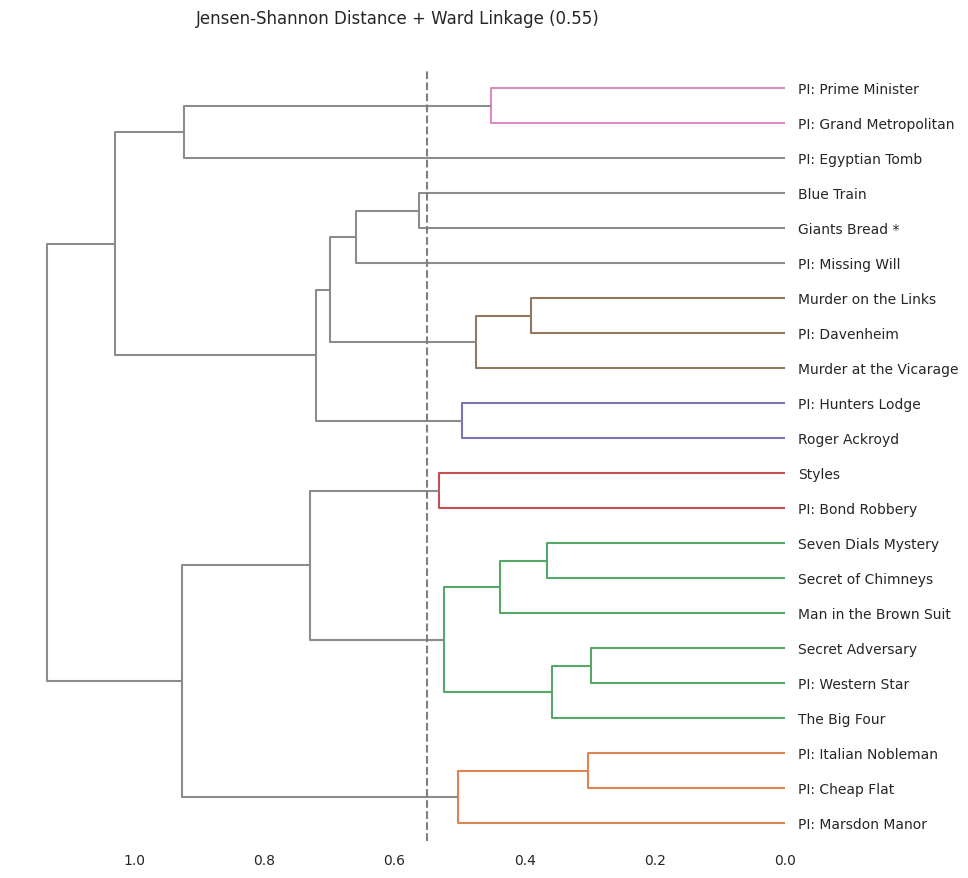

In [173]:
# Generate the cluster tree
tree = sch.linkage(condensed, method='ward')

# Get short titles as labels for the leaves
labels = [short_titles[i] for i in THETA_BOOKS.index]

# choose color_threshold
color_thresh = 0.55

# Create a dendrogram from the tree and plot
plt.figure(figsize=(10, 10))
sch.dendrogram(
    tree, 
    labels=labels, 
    orientation="left", 
    distance_sort=True,
    above_threshold_color='.55',
    color_threshold=color_thresh
)

# Show threshhold
plt.gca().axvline(color_thresh, c='gray', ls='--')

# Change the appearance of ticks, tick labels, and gridlines
plt.tick_params(axis='both', which='major', labelsize=10)    

# Remove borders
sns.despine(left=True, bottom=True)

# Add title
plt.title(f"Jensen-Shannon Distance + Ward Linkage ({color_thresh})", y=1.05)

plt.savefig('plots/riff1_dendrogram.png', dpi=300, bbox_inches='tight')

In [174]:
theme_map = {str(k): v for k, v in TOPICS['theme'].to_dict().items()}

THETA_BOOKS_THEMES = THETA_BOOKS.rename(columns=theme_map).T.groupby(level=0).sum().T

In [175]:
THETA_BOOKS_THEMES.loc[['the-secret-adversary', 'the-murder-of-roger-ackroyd']]

,Background,Clues,Genre Trope,Investigation,Motive,Narrative Structure,Prose Infrastructure
book_id,,,,,,,
the-secret-adversary,0.001515,0.012130,0.083121,0.056258,0.025979,0.617681,0.203316
the-murder-of-roger-ackroyd,0.019675,0.025877,0.008349,0.582953,0.255586,0.029672,0.077887


### Interpretation

TODO: 
- macro split: investigative machinery (Investigation + Motive ~84%) vs narrative scaffolding (Narrative Structure + Prose Infrastructure ~82%)
- asymmetry: puzzle cluster homogeneous at 0.40; adventure cluster fragments → fair-play conventions enforce topical consistency
- caveats: Egyptian Tomb degenerate distribution (T8 ~0.998), Giants Bread ambiguous, orange cluster length artifact risk

## Riff 2: Character Embedding Neighborhoods

### Select Target Characters

In [176]:
target_chars = ['poirot', 'hastings', 'japp', 'georges', 'giraud',
                'marple', 'clement', 'griselda',
                'tommy', 'tuppence',
                'battle', 'bundle', 'caterham', 'eversleigh',
                'race', 'pedler']

# map character to sleuth (from LIB)
char_to_sleuth = {
    'poirot':   'Hercule Poirot',
    'hastings': 'Hercule Poirot',
    'japp':     'Hercule Poirot',
    'georges':  'Hercule Poirot',
    'giraud':   'Hercule Poirot',
    'marple':   'Miss Jane Marple',
    'clement':  'Miss Jane Marple',
    'griselda': 'Miss Jane Marple',
    'tommy':    'Tommy and Tuppence',
    'tuppence': 'Tommy and Tuppence',
    'race':     'Colonel Race',
    'pedler':    'Colonel Race',
    'battle':   'Superintendent Battle',
    'bundle':    'Superintendent Battle',
    'caterham':  'Superintendent Battle',
    'eversleigh': 'Superintendent Battle'
}

### Compute Nearest Neighbors by Cosine Similarity

In [177]:
# get vectors for target characters only
target_vecs = VOCAB_W2V.loc[target_chars]

# compute similarity from each target to all vocab terms
# result is shape (16, vocab_size)
SIM = pd.DataFrame(
    cosine_similarity(target_vecs, VOCAB_W2V),
    index=target_chars,
    columns=VOCAB_W2V.index
)

In [178]:
# get 16x10 table of nearest neighbor names
n = 10
NEIGHBORS = SIM.apply(lambda row: row.nlargest(n+1).iloc[1:].index.tolist(), axis=1) # iloc[1:] skips the character itself (similarity = 1)

### Visualize

Q: Do the embeddings separate Christie's narrative universes?

Hypothesis: I expect that it would given the different styles (and genres) of the detectives.

In [179]:
# get 16x16 cosine similarity matrix for the target characters
SIM_CHARS = SIM[target_chars]

# order characters by sleuth group
char_order = sorted(target_chars, key=lambda c: char_to_sleuth[c])
SIM_CHARS = SIM_CHARS.loc[char_order, char_order]

SIM_CHARS

term_str,race,pedler,poirot,hastings,japp,georges,giraud,marple,clement,griselda,battle,bundle,caterham,eversleigh,tommy,tuppence
race,1.000000,0.631766,0.259096,0.402306,0.553468,0.573875,0.561960,0.688708,0.729616,0.551309,0.489643,0.343201,0.561367,0.725468,0.328331,0.359737
pedler,0.631766,1.000000,0.324287,0.599153,0.761129,0.847353,0.597589,0.653890,0.667919,0.549803,0.568246,0.351682,0.715202,0.660605,0.380259,0.441123
poirot,0.259096,0.324287,1.000000,0.156023,0.626512,0.282015,0.759278,0.365539,0.247822,0.692695,0.686002,0.760591,0.351597,0.277110,0.777556,0.708302
hastings,0.402306,0.599153,0.156023,1.000000,0.353627,0.382094,0.333571,0.536658,0.674878,0.423038,0.367279,0.195586,0.429638,0.439175,0.012637,0.256133
japp,0.553468,0.761129,0.626512,0.353627,1.000000,0.675599,0.731977,0.631381,0.479674,0.746768,0.779820,0.685417,0.666290,0.559544,0.720534,0.717756
georges,0.573875,0.847353,0.282015,0.382094,0.675599,1.000000,0.585354,0.527225,0.545073,0.426754,0.365318,0.285832,0.496107,0.583322,0.349079,0.290159
giraud,0.561960,0.597589,0.759278,0.333571,0.731977,0.585354,1.000000,0.598985,0.511747,0.769740,0.717507,0.688969,0.520056,0.541659,0.733950,0.705119
marple,0.688708,0.653890,0.365539,0.536658,0.631381,0.527225,0.598985,1.000000,0.743029,0.593545,0.639218,0.423813,0.592317,0.731966,0.357655,0.658848
clement,0.729616,0.667919,0.247822,0.674878,0.479674,0.545073,0.511747,0.743029,1.000000,0.424999,0.461620,0.225384,0.433896,0.913455,0.163870,0.364321
griselda,0.551309,0.549803,0.692695,0.423038,0.746768,0.426754,0.769740,0.593545,0.424999,1.000000,0.844612,0.891225,0.482530,0.401757,0.822881,0.816954


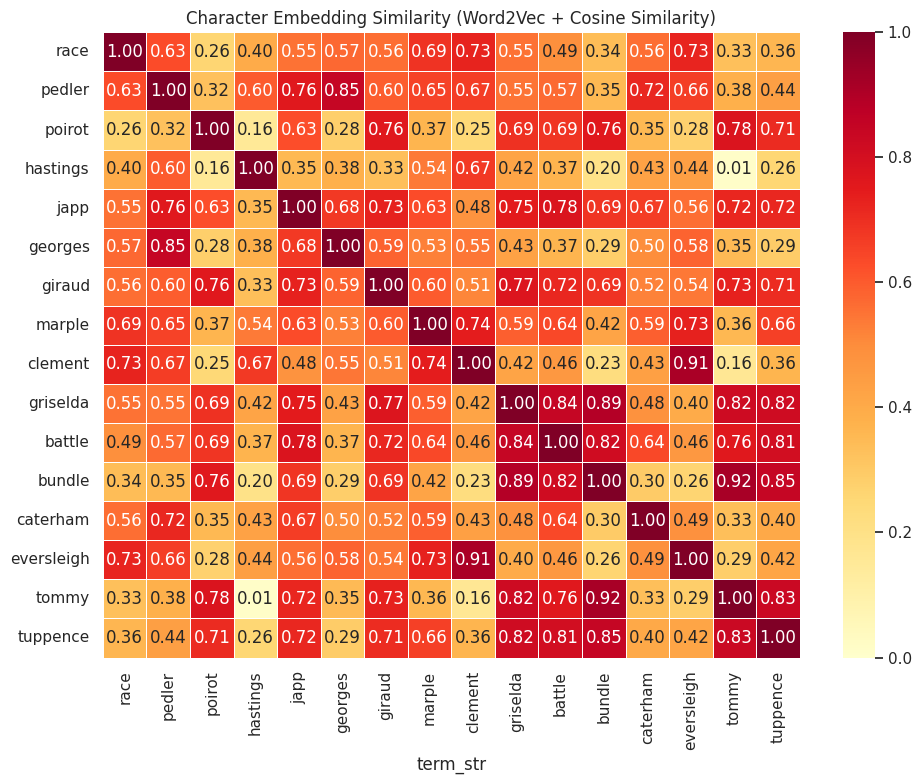

In [182]:
# plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    SIM_CHARS,
    annot=True, # print similarity value as number inside each cell
    fmt='.2f', # format annotation numbers to two decimal places
    cmap='YlOrRd', # color palette
    vmin=0, vmax=1, # anchor color scale to full cosine similarityy range (so that seaborn doesn't auto scale to the data and make small differences look big)
    linewidths=0.5 # put thin glines between cells
)
plt.title('Character Embedding Similarity (Word2Vec + Cosine Similarity)')
plt.tight_layout()
plt.savefig('plots/riff2_character_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretation

Notice that Hastings has low similarity with almost everyone including Poirot. However, this isn't too surprising given that Hastings is the narrator, so the term string hastings would only show up in dialogue. Poirot on the other hand is constantly referenced in narrative, dialogue, and description. The low Poirot-Hastings similarity is likely a result of this asymmetry of reference rather than a signal that they inhabit different semantic spaces. It may be worth further exploration in the future to see if narrator names in general have different co-occurrence distributions than character names.

This itself an artifact of the inscription decision made at tokenization. By treating all tokens as equivalent we erase the narrator/character distinction that a reader would naturally make.

## Riff 3: Books in PCA Space Colored by LIB Metadata

### Load PCA Output

### Join LIB Features

### Visualize

### Interpretation